# Deep Neural Networks & Multi-Class Classification

## Introduction

In this notebook, we build a **deep neural network from scratch** to classify handwritten digits from the MNIST dataset.

### What's New in L5

| L4 | L5 |
|----|----|
| 1 hidden layer | 2 hidden layers |
| Sigmoid activation | ReLU activation |
| Binary classification | Multi-class (10 digits) |
| 1 output neuron | 10 output neurons |
| Sigmoid output | Softmax output |

### Architecture

```
Input (784) → Hidden1 (128) → Hidden2 (64) → Output (10)
              [ReLU]          [ReLU]         [Softmax]
```

### What You'll Learn

- Why **ReLU** is better than sigmoid for deep networks
- How **softmax** converts scores to probabilities
- **Categorical cross-entropy** for multi-class classification
- Training on a real dataset: **MNIST** (handwritten digits)

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# For reproducibility
np.random.seed(42)

## 2. Loading the MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0-9).
- Each image is 28×28 = 784 pixels
- Pixel values range from 0 (black) to 255 (white)

**Our task:** Given 784 pixel values → predict which digit (0-9)

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset (this may take a moment)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_full = mnist.data
y_full = mnist.target.astype(int)

print(f"\nDataset loaded!")
print(f"X shape: {X_full.shape}  (samples, pixels)")
print(f"y shape: {y_full.shape}  (samples,)")
print(f"Pixel value range: [{X_full.min()}, {X_full.max()}]")
print(f"Classes: {np.unique(y_full)}")

Loading MNIST dataset (this may take a moment)...

Dataset loaded!
X shape: (70000, 784)  (samples, pixels)
y shape: (70000,)  (samples,)
Pixel value range: [0, 255]
Classes: [0 1 2 3 4 5 6 7 8 9]


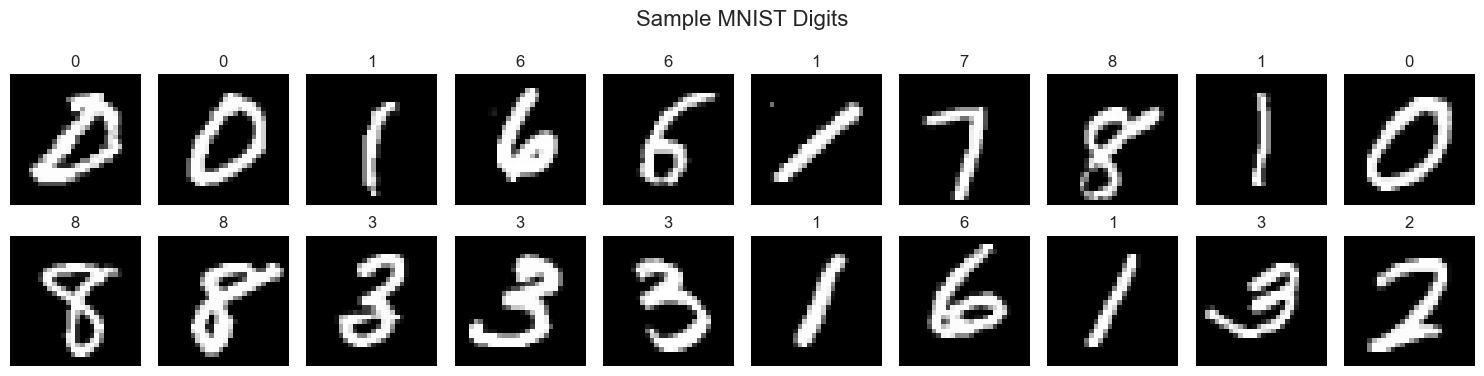

In [3]:
# Visualize some sample digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_full))
    ax.imshow(X_full[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{y_full[idx]}", fontsize=12)
    ax.axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

**Key steps:**
1. **Normalize** pixel values to [0, 1]
2. **Split** into training and test sets
3. **One-hot encode** the labels

We'll use a smaller subset for faster training in this notebook.

In [4]:
# Normalize pixel values to [0, 1]
X_full = X_full / 255.0

print(f"After normalization:")
print(f"Pixel value range: [{X_full.min():.2f}, {X_full.max():.2f}]")

After normalization:
Pixel value range: [0.00, 1.00]


In [5]:
# Use a subset for faster training (10,000 samples)
# You can increase this for better accuracy
n_samples = 10000

X_subset = X_full[:n_samples]
y_subset = y_full[:n_samples]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 8000 samples
Test set: 2000 samples


In [6]:
def one_hot(y, num_classes=10):
    """
    Convert integer labels to one-hot encoded vectors.
    
    Example: 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
    """
    return np.eye(num_classes)[y]

In [7]:
# One-hot encode the labels
Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

print(f"One-hot encoding example:")
print(f"Original label: {y_train[0]}")
print(f"One-hot vector: {Y_train[0]}")
print(f"\nY_train shape: {Y_train.shape}  (samples, classes)")
print(f"Y_test shape: {Y_test.shape}")

One-hot encoding example:
Original label: 6
One-hot vector: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Y_train shape: (8000, 10)  (samples, classes)
Y_test shape: (2000, 10)


## 4. Activation Functions

### ReLU (Rectified Linear Unit)

For hidden layers:
$$\text{ReLU}(z) = \max(0, z)$$

**Why ReLU instead of Sigmoid?**
- Sigmoid derivative is at most 0.25
- In deep networks: $0.25 \times 0.25 \times ... \to 0$ (vanishing gradients!)
- ReLU derivative is 1 for positive values — gradients don't shrink!

### Softmax

For output layer (multi-class):
$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Converts raw scores to probabilities that sum to 1.

In [8]:
def relu(z):
    """ReLU activation function."""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU: 1 if z > 0, else 0."""
    return (z > 0).astype(float)

def softmax(z):
    """
    Softmax activation function (numerically stable).
    
    Converts raw scores to probabilities that sum to 1.
    """
    # Subtract max for numerical stability (avoids overflow)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

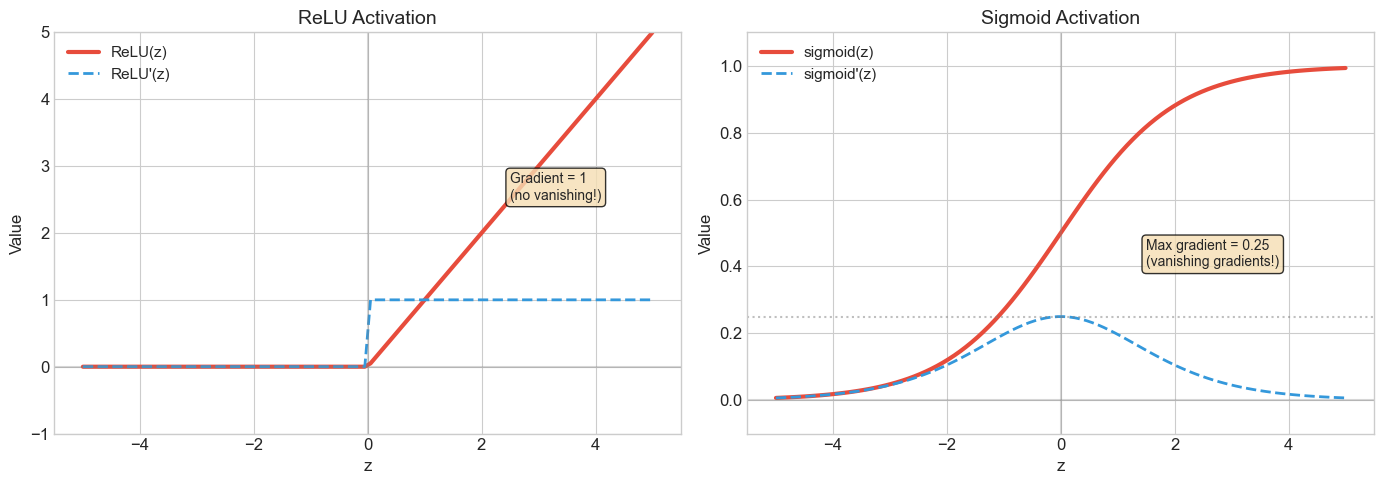

In [9]:
# Visualize ReLU vs Sigmoid
z = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ReLU
ax1 = axes[0]
ax1.plot(z, relu(z), linewidth=3, color='#e74c3c', label='ReLU(z)')
ax1.plot(z, relu_derivative(z), linewidth=2, color='#3498db', linestyle='--', label="ReLU'(z)")
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_xlabel('z', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('ReLU Activation', fontsize=14)
ax1.legend(fontsize=11)
ax1.set_ylim(-1, 5)
ax1.annotate('Gradient = 1\n(no vanishing!)', xy=(2.5, 2.5), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Sigmoid (for comparison)
ax2 = axes[1]
sigmoid = lambda z: 1 / (1 + np.exp(-z))
sigmoid_deriv = lambda z: sigmoid(z) * (1 - sigmoid(z))
ax2.plot(z, sigmoid(z), linewidth=3, color='#e74c3c', label='sigmoid(z)')
ax2.plot(z, sigmoid_deriv(z), linewidth=2, color='#3498db', linestyle='--', label="sigmoid'(z)")
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Sigmoid Activation', fontsize=14)
ax2.legend(fontsize=11)
ax2.set_ylim(-0.1, 1.1)
ax2.annotate('Max gradient = 0.25\n(vanishing gradients!)', xy=(1.5, 0.4), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [10]:
# Demonstrate softmax
z_example = np.array([[2.0, 1.0, 0.1, 3.0, 0.5, 0.2, 0.1, 0.3, 0.2, 0.1]])
probs = softmax(z_example)

print("Softmax Example:")
print("="*60)
print(f"Raw scores (z): {z_example[0]}")
print(f"Probabilities:  {probs[0].round(3)}")
print(f"Sum of probs:   {probs.sum():.4f} (should be 1.0)")
print(f"Predicted class: {np.argmax(probs)} (highest probability: {probs.max():.3f})")

Softmax Example:
Raw scores (z): [2.  1.  0.1 3.  0.5 0.2 0.1 0.3 0.2 0.1]
Probabilities:  [0.19  0.07  0.028 0.516 0.042 0.031 0.028 0.035 0.031 0.028]
Sum of probs:   1.0000 (should be 1.0)
Predicted class: 3 (highest probability: 0.516)


## 5. Network Architecture

We'll build a 3-layer network:
- **Input**: 784 neurons (28×28 pixels)
- **Hidden 1**: 128 neurons with ReLU
- **Hidden 2**: 64 neurons with ReLU
- **Output**: 10 neurons with Softmax (one per digit class)

In [11]:
# Network architecture
n_input = 784    # 28x28 pixels
n_hidden1 = 128  # First hidden layer
n_hidden2 = 64   # Second hidden layer
n_output = 10    # 10 digit classes

print("NETWORK ARCHITECTURE")
print("="*60)
print(f"Input layer:   {n_input} neurons (784 pixels)")
print(f"Hidden layer 1: {n_hidden1} neurons (ReLU activation)")
print(f"Hidden layer 2: {n_hidden2} neurons (ReLU activation)")
print(f"Output layer:  {n_output} neurons (Softmax activation)")
print("="*60)
print(f"\nWeight matrix shapes:")
print(f"W1: ({n_input}, {n_hidden1}) = {n_input * n_hidden1:,} parameters")
print(f"W2: ({n_hidden1}, {n_hidden2}) = {n_hidden1 * n_hidden2:,} parameters")
print(f"W3: ({n_hidden2}, {n_output}) = {n_hidden2 * n_output:,} parameters")
print(f"\nTotal parameters: {n_input * n_hidden1 + n_hidden1 * n_hidden2 + n_hidden2 * n_output:,}")

NETWORK ARCHITECTURE
Input layer:   784 neurons (784 pixels)
Hidden layer 1: 128 neurons (ReLU activation)
Hidden layer 2: 64 neurons (ReLU activation)
Output layer:  10 neurons (Softmax activation)

Weight matrix shapes:
W1: (784, 128) = 100,352 parameters
W2: (128, 64) = 8,192 parameters
W3: (64, 10) = 640 parameters

Total parameters: 109,184


## 6. Weight Initialization

For ReLU networks, we use **He initialization**: scale weights by $\sqrt{2/n_{\text{in}}}$ where $n_{\text{in}}$ is the number of inputs to the layer.

This prevents gradients from vanishing or exploding at the start of training.

In [12]:
def initialize_weights(seed=42):
    """Initialize weights using He initialization (good for ReLU)."""
    np.random.seed(seed)
    
    # He initialization: scale by sqrt(2/n_in) for ReLU networks
    W1 = np.random.randn(n_input, n_hidden1) * np.sqrt(2.0 / n_input)
    W2 = np.random.randn(n_hidden1, n_hidden2) * np.sqrt(2.0 / n_hidden1)
    W3 = np.random.randn(n_hidden2, n_output) * np.sqrt(2.0 / n_hidden2)
    
    return W1, W2, W3

In [13]:
# Initialize weights
W1, W2, W3 = initialize_weights()

print("INITIALIZED WEIGHTS")
print("="*60)
print(f"W1 shape: {W1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"W3 shape: {W3.shape}")

INITIALIZED WEIGHTS
W1 shape: (784, 128)
W2 shape: (128, 64)
W3 shape: (64, 10)


## 7. Forward Propagation

**For each layer:**
1. Linear transformation: $\mathbf{z}^{[l]} = \mathbf{a}^{[l-1]} \cdot \mathbf{W}^{[l]}$
2. Activation: $\mathbf{a}^{[l]} = g(\mathbf{z}^{[l]})$

Where $g$ is ReLU for hidden layers and Softmax for output.

In [14]:
def forward(X, W1, W2, W3):
    """
    Forward propagation through the network.
    
    Returns all intermediate values (needed for backprop).
    """
    # Layer 1: Input → Hidden 1 (ReLU)
    z1 = np.dot(X, W1)       # (m, 784) · (784, 128) = (m, 128)
    a1 = relu(z1)             # (m, 128)
    
    # Layer 2: Hidden 1 → Hidden 2 (ReLU)
    z2 = np.dot(a1, W2)      # (m, 128) · (128, 64) = (m, 64)
    a2 = relu(z2)             # (m, 64)
    
    # Layer 3: Hidden 2 → Output (Softmax)
    z3 = np.dot(a2, W3)      # (m, 64) · (64, 10) = (m, 10)
    h = softmax(z3)           # (m, 10)
    
    return z1, a1, z2, a2, z3, h

In [15]:
# Test forward propagation with dimension checks
z1, a1, z2, a2, z3, h = forward(X_train, W1, W2, W3)
m = len(X_train)

print("FORWARD PROPAGATION - DIMENSION CHECK")
print("="*60)
print(f"\nLayer 1 (Input → Hidden 1):")
print(f"  X shape:   {X_train.shape}")
print(f"  W1 shape:  {W1.shape}")
print(f"  z1 = X · W1")
print(f"  z1 shape:  {z1.shape}  ← ({m}, 784) · (784, 128) = ({m}, 128)")
print(f"  a1 = ReLU(z1)")
print(f"  a1 shape:  {a1.shape}")

print(f"\nLayer 2 (Hidden 1 → Hidden 2):")
print(f"  a1 shape:  {a1.shape}")
print(f"  W2 shape:  {W2.shape}")
print(f"  z2 = a1 · W2")
print(f"  z2 shape:  {z2.shape}  ← ({m}, 128) · (128, 64) = ({m}, 64)")
print(f"  a2 = ReLU(z2)")
print(f"  a2 shape:  {a2.shape}")

print(f"\nLayer 3 (Hidden 2 → Output):")
print(f"  a2 shape:  {a2.shape}")
print(f"  W3 shape:  {W3.shape}")
print(f"  z3 = a2 · W3")
print(f"  z3 shape:  {z3.shape}  ← ({m}, 64) · (64, 10) = ({m}, 10)")
print(f"  h = softmax(z3)")
print(f"  h shape:   {h.shape}")

print(f"\n" + "="*60)
print(f"✓ Output shape {h.shape} = (samples, classes)")
print(f"✓ Probabilities sum to 1: {h[0].sum():.4f}")

FORWARD PROPAGATION - DIMENSION CHECK

Layer 1 (Input → Hidden 1):
  X shape:   (8000, 784)
  W1 shape:  (784, 128)
  z1 = X · W1
  z1 shape:  (8000, 128)  ← (8000, 784) · (784, 128) = (8000, 128)
  a1 = ReLU(z1)
  a1 shape:  (8000, 128)

Layer 2 (Hidden 1 → Hidden 2):
  a1 shape:  (8000, 128)
  W2 shape:  (128, 64)
  z2 = a1 · W2
  z2 shape:  (8000, 64)  ← (8000, 128) · (128, 64) = (8000, 64)
  a2 = ReLU(z2)
  a2 shape:  (8000, 64)

Layer 3 (Hidden 2 → Output):
  a2 shape:  (8000, 64)
  W3 shape:  (64, 10)
  z3 = a2 · W3
  z3 shape:  (8000, 10)  ← (8000, 64) · (64, 10) = (8000, 10)
  h = softmax(z3)
  h shape:   (8000, 10)

✓ Output shape (8000, 10) = (samples, classes)
✓ Probabilities sum to 1: 1.0000


## 8. Cost Function: Categorical Cross-Entropy

$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(h_k^{(i)})$$

Since $y$ is one-hot encoded, only the term for the true class contributes:

$$J = -\frac{1}{m} \sum_{i=1}^{m} \log(h_{\text{true class}}^{(i)})$$

In [16]:
def compute_cost(h, Y):
    """
    Compute categorical cross-entropy loss.
    
    Parameters:
    - h: predicted probabilities (m, K)
    - Y: one-hot encoded true labels (m, K)
    
    Returns:
    - cost: average cross-entropy loss
    """
    m = len(Y)
    # Clip to avoid log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    # Cross-entropy: -sum(y * log(h)) for each sample, then average
    cost = -np.sum(Y * np.log(h)) / m
    return cost

In [17]:
# Test cost function
initial_cost = compute_cost(h, Y_train)
print(f"Initial cost (random weights): {initial_cost:.4f}")
print(f"Expected for random guess (10 classes): {-np.log(1/10):.4f}")

Initial cost (random weights): 2.4427
Expected for random guess (10 classes): 2.3026


## 9. Backpropagation

**Key insight:** For softmax + cross-entropy, the output error is beautifully simple:
$$\delta^{[3]} = h - \mathbf{Y}$$

Then propagate backwards through each layer:
$$\delta^{[l]} = (\delta^{[l+1]} \cdot (\mathbf{W}^{[l+1]})^T) \odot \text{ReLU}'(\mathbf{z}^{[l]})$$

$$\nabla_{\mathbf{W}^{[l]}}J = \frac{1}{m}(\mathbf{a}^{[l-1]})^T \cdot \delta^{[l]}$$

In [18]:
def backward(X, Y, z1, a1, z2, a2, h, W2, W3):
    """
    Backpropagation to compute gradients.
    
    Parameters:
    - X: input data
    - Y: one-hot encoded true labels
    - z1, a1, z2, a2, h: values from forward pass
    - W2, W3: weights (needed to propagate error back)
    
    Returns:
    - dW1, dW2, dW3: gradients for each weight matrix
    """
    m = len(Y)
    
    # Output layer error (softmax + cross-entropy → h - Y)
    delta3 = h - Y                                      # (m, 10)
    
    # Gradient for W3
    dW3 = np.dot(a2.T, delta3) / m                      # (64, 10)
    
    # Hidden layer 2 error
    delta2 = np.dot(delta3, W3.T) * relu_derivative(z2) # (m, 64)
    
    # Gradient for W2
    dW2 = np.dot(a1.T, delta2) / m                      # (128, 64)
    
    # Hidden layer 1 error
    delta1 = np.dot(delta2, W2.T) * relu_derivative(z1) # (m, 128)
    
    # Gradient for W1
    dW1 = np.dot(X.T, delta1) / m                       # (784, 128)
    
    return dW1, dW2, dW3

In [19]:
# Test backpropagation with dimension checks
dW1, dW2, dW3 = backward(X_train, Y_train, z1, a1, z2, a2, h, W2, W3)

print("BACKPROPAGATION - DIMENSION CHECK")
print("="*60)
print(f"\nGradient shapes must match weight shapes:")
print(f"  dW1: {dW1.shape} ← matches W1: {W1.shape}? ✓")
print(f"  dW2: {dW2.shape} ← matches W2: {W2.shape}? ✓")
print(f"  dW3: {dW3.shape} ← matches W3: {W3.shape}? ✓")

BACKPROPAGATION - DIMENSION CHECK

Gradient shapes must match weight shapes:
  dW1: (784, 128) ← matches W1: (784, 128)? ✓
  dW2: (128, 64) ← matches W2: (128, 64)? ✓
  dW3: (64, 10) ← matches W3: (64, 10)? ✓


## 10. Training the Network

Same training loop as L4:
1. Forward pass
2. Compute cost
3. Backward pass
4. Update weights

In [20]:
def train(X_train, Y_train, X_test, Y_test, lr=0.1, epochs=50, print_every=5):
    """
    Train the neural network.
    
    Parameters:
    - X_train, Y_train: training data
    - X_test, Y_test: test data for evaluation
    - lr: learning rate
    - epochs: number of training epochs
    - print_every: print progress every N epochs
    
    Returns:
    - W1, W2, W3: trained weights
    - history: dict with training history
    """
    # Initialize weights
    W1, W2, W3 = initialize_weights()
    
    # Track history
    history = {
        'train_cost': [], 'test_cost': [],
        'train_acc': [], 'test_acc': []
    }
    
    print(f"Training neural network...")
    print(f"Architecture: 784 → 128 → 64 → 10")
    print(f"Learning rate: {lr}, Epochs: {epochs}")
    print("="*70)
    
    for epoch in range(epochs):
        # Forward pass
        z1, a1, z2, a2, z3, h = forward(X_train, W1, W2, W3)
        
        # Backward pass
        dW1, dW2, dW3 = backward(X_train, Y_train, z1, a1, z2, a2, h, W2, W3)
        
        # Update weights
        W1 = W1 - lr * dW1
        W2 = W2 - lr * dW2
        W3 = W3 - lr * dW3
        
        # Compute metrics
        train_cost = compute_cost(h, Y_train)
        train_pred = np.argmax(h, axis=1)
        train_acc = np.mean(train_pred == np.argmax(Y_train, axis=1))
        
        # Test set evaluation
        _, _, _, _, _, h_test = forward(X_test, W1, W2, W3)
        test_cost = compute_cost(h_test, Y_test)
        test_pred = np.argmax(h_test, axis=1)
        test_acc = np.mean(test_pred == np.argmax(Y_test, axis=1))
        
        # Save history
        history['train_cost'].append(train_cost)
        history['test_cost'].append(test_cost)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        # Print progress
        if epoch % print_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"Train Loss: {train_cost:.4f}, Train Acc: {train_acc:.2%} | "
                  f"Test Acc: {test_acc:.2%}")
    
    print("="*70)
    print(f"Final Test Accuracy: {history['test_acc'][-1]:.2%}")
    
    return W1, W2, W3, history

In [21]:
# Train the network!
W1_trained, W2_trained, W3_trained, history = train(
    X_train, Y_train, 
    X_test, Y_test,
    lr=0.1,
    epochs=50,
    print_every=5
)

Training neural network...
Architecture: 784 → 128 → 64 → 10
Learning rate: 0.1, Epochs: 50
Epoch   1/50: Train Loss: 2.4427, Train Acc: 7.96% | Test Acc: 12.10%
Epoch   6/50: Train Loss: 1.9838, Train Acc: 41.52% | Test Acc: 51.20%
Epoch  11/50: Train Loss: 1.5966, Train Acc: 63.98% | Test Acc: 67.35%
Epoch  16/50: Train Loss: 1.2621, Train Acc: 71.84% | Test Acc: 74.10%
Epoch  21/50: Train Loss: 1.0189, Train Acc: 77.33% | Test Acc: 78.45%
Epoch  26/50: Train Loss: 0.8540, Train Acc: 80.47% | Test Acc: 81.35%
Epoch  31/50: Train Loss: 0.7428, Train Acc: 82.60% | Test Acc: 83.30%
Epoch  36/50: Train Loss: 0.6650, Train Acc: 83.84% | Test Acc: 84.30%
Epoch  41/50: Train Loss: 0.6081, Train Acc: 84.92% | Test Acc: 85.15%
Epoch  46/50: Train Loss: 0.5649, Train Acc: 85.79% | Test Acc: 85.45%
Epoch  50/50: Train Loss: 0.5371, Train Acc: 86.16% | Test Acc: 86.25%
Final Test Accuracy: 86.25%


## 11. Visualizing Training Progress

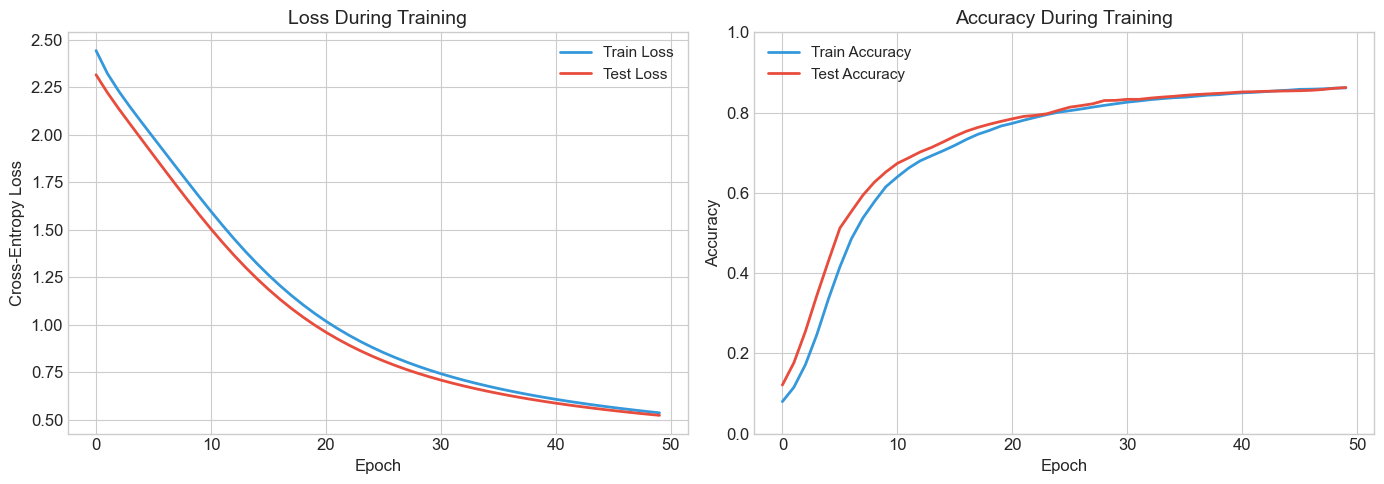

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
ax1 = axes[0]
ax1.plot(history['train_cost'], linewidth=2, color='#3498db', label='Train Loss')
ax1.plot(history['test_cost'], linewidth=2, color='#e74c3c', label='Test Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Loss During Training', fontsize=14)
ax1.legend(fontsize=11)

# Plot 2: Accuracy
ax2 = axes[1]
ax2.plot(history['train_acc'], linewidth=2, color='#3498db', label='Train Accuracy')
ax2.plot(history['test_acc'], linewidth=2, color='#e74c3c', label='Test Accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy During Training', fontsize=14)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 12. Visualizing Predictions

In [23]:
# Make predictions on test set
_, _, _, _, _, h_test = forward(X_test, W1_trained, W2_trained, W3_trained)
predictions = np.argmax(h_test, axis=1)
true_labels = np.argmax(Y_test, axis=1)

# Find correct and incorrect predictions
correct_mask = predictions == true_labels
incorrect_mask = ~correct_mask

print(f"Test Accuracy: {correct_mask.mean():.2%}")
print(f"Correct predictions: {correct_mask.sum()}")
print(f"Incorrect predictions: {incorrect_mask.sum()}")

Test Accuracy: 86.25%
Correct predictions: 1725
Incorrect predictions: 275


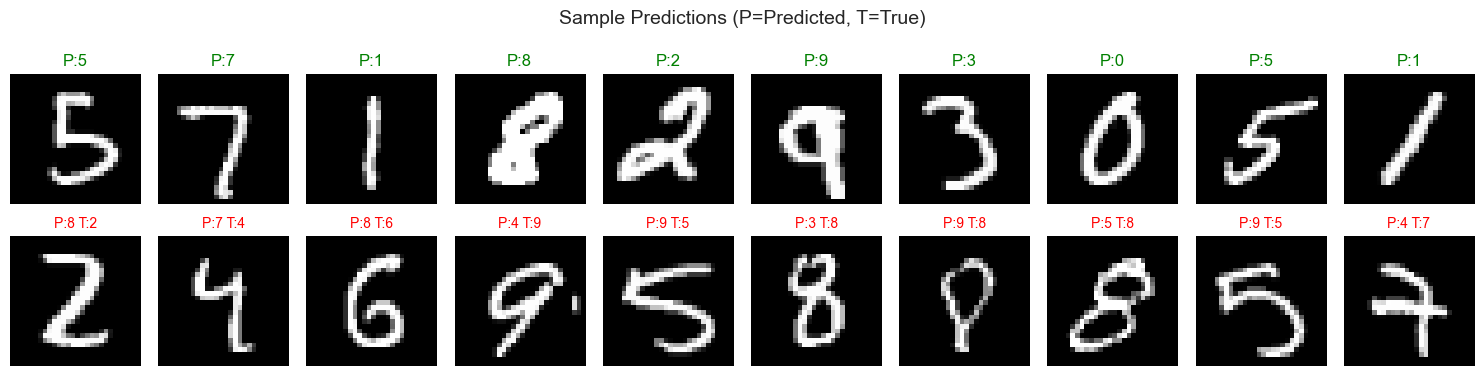

In [24]:
# Show sample predictions
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Top row: Correct predictions
correct_indices = np.where(correct_mask)[0]
for i, ax in enumerate(axes[0]):
    idx = correct_indices[np.random.randint(len(correct_indices))]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"P:{predictions[idx]}", color='green', fontsize=12)
    ax.axis('off')

# Bottom row: Incorrect predictions (if any)
incorrect_indices = np.where(incorrect_mask)[0]
for i, ax in enumerate(axes[1]):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"P:{predictions[idx]} T:{true_labels[idx]}", color='red', fontsize=10)
    ax.axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=12)
axes[1, 0].set_ylabel('Wrong', fontsize=12)
plt.suptitle('Sample Predictions (P=Predicted, T=True)', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Confusion Matrix

Let's see which digits are most often confused with each other.

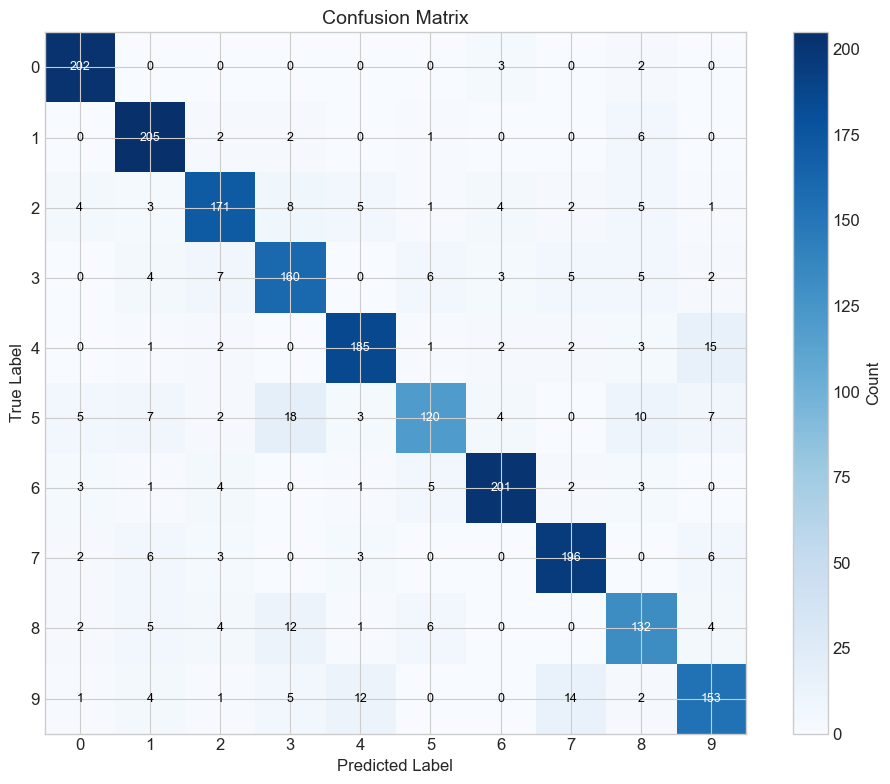


Per-class accuracy:
  Digit 0: 97.6%
  Digit 1: 94.9%
  Digit 2: 83.8%
  Digit 3: 83.3%
  Digit 4: 87.7%
  Digit 5: 68.2%
  Digit 6: 91.4%
  Digit 7: 90.7%
  Digit 8: 79.5%
  Digit 9: 79.7%


In [25]:
# Compute confusion matrix
confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(true_labels, predictions):
    confusion[true, pred] += 1

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion, cmap='Blues')

# Add labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

# Add text annotations
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, confusion[i, j], ha='center', va='center', 
                      color='white' if confusion[i, j] > confusion.max()/2 else 'black',
                      fontsize=9)

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i in range(10):
    class_acc = confusion[i, i] / confusion[i].sum() if confusion[i].sum() > 0 else 0
    print(f"  Digit {i}: {class_acc:.1%}")

## 14. Interactive Prediction Demo

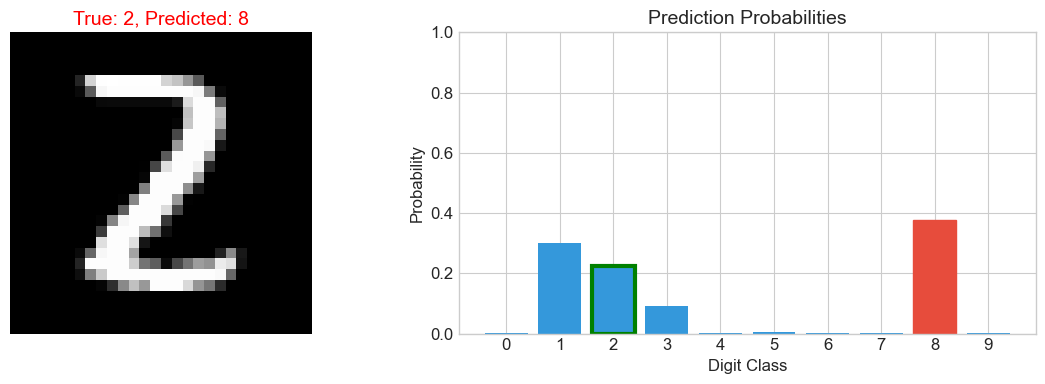

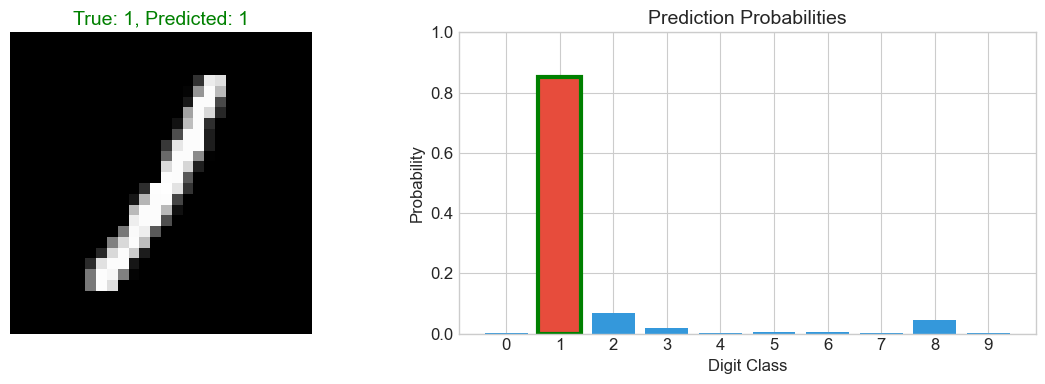

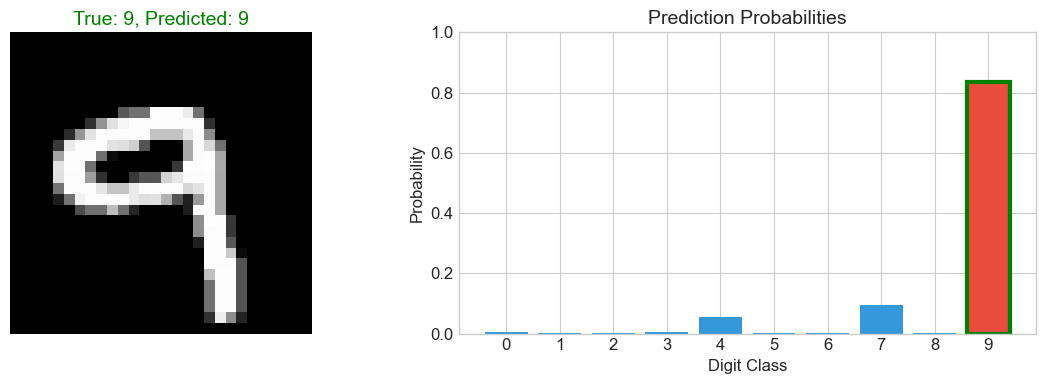

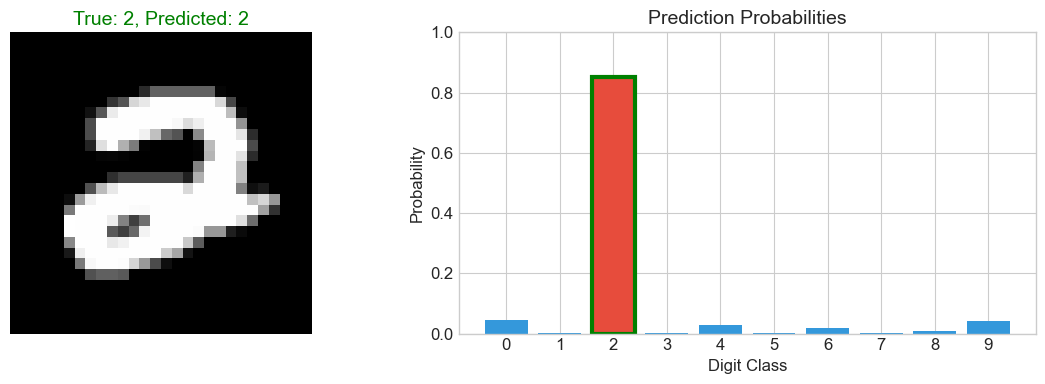

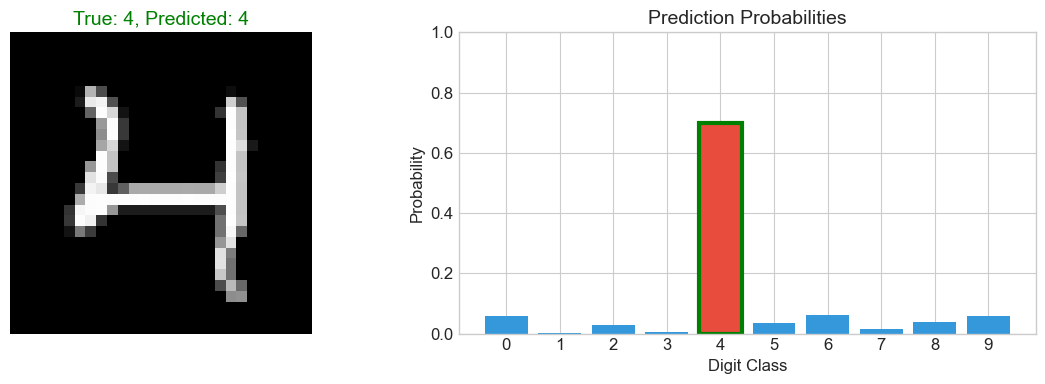

In [26]:
def predict_and_show(idx):
    """
    Show a sample image with prediction probabilities.
    """
    # Get sample
    x = X_test[idx:idx+1]
    y_true = true_labels[idx]
    
    # Predict
    _, _, _, _, _, h = forward(x, W1_trained, W2_trained, W3_trained)
    probs = h[0]
    y_pred = np.argmax(probs)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Image
    ax1 = axes[0]
    ax1.imshow(x.reshape(28, 28), cmap='gray')
    color = 'green' if y_pred == y_true else 'red'
    ax1.set_title(f'True: {y_true}, Predicted: {y_pred}', fontsize=14, color=color)
    ax1.axis('off')
    
    # Probabilities
    ax2 = axes[1]
    bars = ax2.bar(range(10), probs, color='#3498db')
    bars[y_pred].set_color('#e74c3c')
    bars[y_true].set_edgecolor('green')
    bars[y_true].set_linewidth(3)
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Digit Class', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Prediction Probabilities', fontsize=14)
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Show a few examples
for idx in [0, 50, 100, 150, 200]:
    predict_and_show(idx)

## 15. Summary

### What We Built

A deep neural network from scratch that classifies handwritten digits:

| Component | Details |
|-----------|----------|
| Architecture | 784 → 128 → 64 → 10 |
| Hidden Activations | ReLU |
| Output Activation | Softmax |
| Loss Function | Categorical Cross-Entropy |

### Key Formulas

**ReLU:**
$$\text{ReLU}(z) = \max(0, z), \quad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

**Softmax:**
$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

**Categorical Cross-Entropy:**
$$J = -\frac{1}{m}\sum_i \sum_k y_k^{(i)} \log h_k^{(i)}$$

**Output Error (softmax + cross-entropy):**
$$\delta^{[L]} = h - \mathbf{Y}$$

### What's Next ?

- **PyTorch/Keras**: Automatic differentiation, GPU acceleration
- Rapidly experiment with different architectures
- Build more complex networks

In [27]:
# Final summary
print("="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Dataset:           MNIST (handwritten digits 0-9)")
print(f"Training samples:  {len(X_train):,}")
print(f"Test samples:      {len(X_test):,}")
print(f"Architecture:      784 → 128 → 64 → 10")
print(f"Total parameters:  {W1_trained.size + W2_trained.size + W3_trained.size:,}")
print(f"Epochs:            {len(history['train_cost'])}")
print(f"Final Train Acc:   {history['train_acc'][-1]:.2%}")
print(f"Final Test Acc:    {history['test_acc'][-1]:.2%}")
print("="*70)

TRAINING SUMMARY
Dataset:           MNIST (handwritten digits 0-9)
Training samples:  8,000
Test samples:      2,000
Architecture:      784 → 128 → 64 → 10
Total parameters:  109,184
Epochs:            50
Final Train Acc:   86.16%
Final Test Acc:    86.25%
